<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook Explanation

This section provides a detailed explanation of each executed code cell, covering its purpose, the processes involved, and the insights derived.

In [3]:

# Data Manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Statistics
import scipy.stats as stats

#Miscellaneous
import warnings
warnings.filterwarnings("ignore")

#Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

from datetime import datetime


###  Initial Setup and Library Imports

This cell is responsible for importing necessary libraries and configuring display options for better readability of dataframes.

```python
# Data Manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Statistics
import scipy.stats as stats

#Miscellaneous
import warnings
warnings.filterwarnings("ignore")

#Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

from datetime import datetime
```

**Meaning & Process:**
*   **`pandas` and `numpy`**: Essential for data manipulation and numerical operations.
*   **`matplotlib.pyplot` and `seaborn`**: Used for data visualization.
*   **`scipy.stats`**: For statistical analysis.
*   **`warnings.filterwarnings("ignore")`**: Suppresses warnings to keep the output clean.
*   **`pd.set_option(...)`**: Configures pandas to display all columns and up to 100 rows of a DataFrame without truncation, and sets the display width to 120 characters.
*   **`datetime`**: Imports the `datetime` module for date and time handling.

**Insights:** This cell sets up the environment, ensuring all required tools are available and that DataFrames will be displayed comprehensively.

In [4]:
df = pd.read_csv("marvel_cast.csv")
df = pd.read_csv("marvel_master.csv")
df = pd.read_csv("marvel_rag.csv")
df = pd.read_csv("marvel_ratings.csv")

### Data Loading

This cell attempts to load data from multiple CSV files into a DataFrame named `df`.

```python
df = pd.read_csv("marvel_cast.csv")
df = pd.read_csv("marvel_master.csv")
df = pd.read_csv("marvel_rag.csv")
df = pd.read_csv("marvel_ratings.csv")
```

**Meaning & Process:** Each line reads a different CSV file and assigns it to the variable `df`. Due to this sequential assignment, `df` is repeatedly overwritten. Only the data from the *last* `pd.read_csv()` call (`marvel_ratings.csv`) is retained in the `df` DataFrame.

**Insights:** The DataFrame `df` currently holds the content of `marvel_ratings.csv`. If data from other files was intended to be combined or analyzed separately, the loading logic needs to be revised (e.g., loading into different DataFrames or concatenating them).

In [5]:
df.head()


,title,year,source,score
0,Captain America,1944,IMDb,5.3
1,Captain America,1944,TMDB,5.4
2,The Amazing Spider-Man,1977,IMDb,6.2
3,The Amazing Spider-Man,1977,TMDB,6.3
4,Spider-Man,1977,IMDb,6.2


### Displaying the Head of the DataFrame

This cell shows the first few rows of the loaded DataFrame.

```python
df.head()
```

**Meaning & Process:** The `.head()` method, when called without arguments, returns the first 5 rows of the DataFrame. This is a common first step to quickly inspect the data's structure, column names, and initial values.

**Output Insights:** The output shows that the `df` DataFrame contains columns such as 'title', 'year', 'source', and 'score'. We can see entries for titles like 'Captain America' and 'The Amazing Spider-Man', along with their release years, data sources (IMDb, TMDB), and associated scores. The `score` column appears to contain numerical values, but some are presented as strings.

In [6]:
df.tail()

,title,year,source,score
549,Wonder Man,2026,IMDb,7.4
550,Wonder Man,2026,TMDB,7.019
551,Daredevil: Born Again,2026,IMDb,7.8
552,Daredevil: Born Again,2026,TMDB,7.0
553,Spider-Man: Brand New Day,2026,TMDB,0.0


### Displaying the Tail of the DataFrame

This cell displays the last few rows of the DataFrame.

```python
df.tail()
```

**Meaning & Process:** Similar to `.head()`, the `.tail()` method returns the last 5 rows of the DataFrame by default. This helps in understanding the end of the dataset, especially useful for time-series data or to spot any trailing anomalies.

**Output Insights:** The output shows recent and future titles like 'Wonder Man' and 'Daredevil: Born Again' extending up to the year 2026. This confirms the dataset includes projections or upcoming releases. Notably, one entry for 'Spider-Man: Brand New Day' shows a score of '0.0', which might be a placeholder or an actual score that needs cleaning.

In [7]:
df.shape



(554, 4)

### Checking DataFrame Dimensions

This cell determines the number of rows and columns in the DataFrame.

```python
df.shape
```

**Meaning & Process:** The `.shape` attribute returns a tuple representing the dimensions of the DataFrame, where the first element is the number of rows and the second is the number of columns.

**Output Insights:** The output `(554, 4)` indicates that the DataFrame `df` contains 554 rows and 4 columns. This gives a quick understanding of the dataset's overall size.

In [8]:
df.columns


Index(['title', 'year', 'source', 'score'], dtype='object')

### Listing Column Names

This cell retrieves all column names present in the DataFrame.

```python
df.columns
```

**Meaning & Process:** The `.columns` attribute returns an Index object containing the labels of the DataFrame's columns. This is crucial for verifying column names for subsequent operations.

**Output Insights:** The columns are 'title', 'year', 'source', and 'score'. This confirms the exact spelling and case for referencing these columns.

In [9]:
df.dtypes


,0
title,object
year,int64
source,object
score,object


###  Checking Data Types of Columns

This cell displays the data type of each column in the DataFrame.

```python
df.dtypes
```

**Meaning & Process:** The `.dtypes` attribute returns a Series with the data type of each column. Understanding data types is essential for correct data manipulation and analysis (e.g., performing numerical operations on numeric types, string operations on object types).

**Output Insights:**
*   `title`: `object` (expected, as it contains text strings).
*   `year`: `int64` (expected, as it contains whole numbers representing years).
*   `source`: `object` (expected, as it contains text strings like 'IMDb', 'TMDB').
*   `score`: `object` (This is a key insight. Although 'score' values appear numeric, its `object` type indicates it contains mixed types or strings that need conversion to a numeric format before mathematical operations can be reliably performed).

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   554 non-null    object
 1   year    554 non-null    int64 
 2   source  554 non-null    object
 3   score   369 non-null    object
dtypes: int64(1), object(3)
memory usage: 17.4+ KB


### Comprehensive DataFrame Information

This cell provides a concise summary of the DataFrame, including data types, non-null values, and memory usage.

```python
df.info()
```

**Meaning & Process:** The `.info()` method prints a summary of a DataFrame. This includes the index dtype and columns, non-null values, and memory usage. It's an excellent way to get a quick overview of the data's health.

**Output Insights:**
*   **RangeIndex:** 554 entries (0 to 553), confirming the number of rows.
*   **Columns:** 4 columns total.
*   **Non-Null Count:** 'title', 'year', and 'source' all have 554 non-null entries, meaning they are complete. The 'score' column, however, has only 369 non-null entries, indicating 185 missing values (`554 - 369 = 185`).
*   **Dtype:** Confirms 'year' as `int64` and 'title', 'source', 'score' as `object` (string-like).

**Key Insight:** The `score` column has a significant number of missing values (185) and is of `object` type, which will require cleaning and conversion for numerical analysis.

In [11]:
df.describe()

,year
count,554.000000
mean,2013.066787
std,11.191295
min,1944.000000
25%,2010.000000
50%,2016.000000
75%,2020.000000
max,2026.000000


### Descriptive Statistics

This cell generates descriptive statistics for numerical columns in the DataFrame.

```python
df.describe()
```

**Meaning & Process:** The `.describe()` method generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution, excluding `NaN` values. By default, it works only on numerical columns. Since 'year' is the only numerical column, only its statistics are shown.

**Output Insights (for 'year' column):**
*   **`count` (554)**: All rows have a 'year' value.
*   **`mean` (2013.07)**: The average release year.
*   **`std` (11.19)**: The standard deviation, indicating the spread of years.
*   **`min` (1944)**: The earliest release year in the dataset.
*   **`25%`, `50%` (median), `75%`**: Quartiles indicating the distribution of release years (e.g., half of the titles were released after 2016).
*   **`max` (2026)**: The latest (potentially projected) release year.

**Key Insight:** The 'year' column spans a wide range from 1944 to 2026, suggesting a dataset that covers a long history of Marvel content, including future releases.

In [12]:
df["year"].mean()

np.float64(2013.0667870036102)

### Mean of 'year'

This cell calculates the arithmetic mean of the 'year' column.

```python
df["year"].mean()
```

**Meaning & Process:** The `.mean()` method calculates the average value of the 'year' column. It's a measure of central tendency.

**Output Insights:** The mean release year is approximately 2013.07, providing a central point around which the years are distributed.

In [13]:
df["year"].median()

2016.0

### Median of 'year'

This cell calculates the median of the 'year' column.

```python
df["year"].median()
```

**Meaning & Process:** The `.median()` method returns the middle value of the 'year' column when sorted. It is less sensitive to outliers than the mean.

**Output Insights:** The median release year is 2016.0. Since the median (2016) is slightly higher than the mean (2013), it suggests a slight left skew (more data points on the higher end of the distribution, or a few older outliers pulling the mean down). Alternatively, it could indicate a concentration of releases in more recent years.

In [14]:

df["year"].mode()


,year
0,2018


### Mode of 'year'

This cell finds the most frequent release year in the 'year' column.

```python
df["year"].mode()
```

**Meaning & Process:** The `.mode()` method returns the most frequently occurring value(s) in the 'year' column. A column can have multiple modes.

**Output Insights:** The mode is 2018. This indicates that 2018 is the year with the highest number of Marvel content releases in this dataset.

In [15]:
df["year"].min()


1944

### Minimum Year

This cell identifies the earliest release year.

```python
df["year"].min()
```

**Meaning & Process:** The `.min()` method returns the smallest value in the 'year' column.

**Output Insights:** The minimum year is 1944. This shows the historical depth of the Marvel data, covering content from the mid-20th century.

In [16]:
df["year"].max()


2026

### Maximum Year

This cell identifies the latest release year.

```python
df["year"].max()
```

**Meaning & Process:** The `.max()` method returns the largest value in the 'year' column.

**Output Insights:** The maximum year is 2026. This confirms the dataset includes future or projected releases.

In [17]:
df["year"].std()


11.191294802236794

### Standard Deviation of 'year'

This cell calculates the standard deviation of the 'year' column.

```python
df["year"].std()
```

**Meaning & Process:** The `.std()` method calculates the standard deviation, which measures the amount of variation or dispersion of a set of values. A low standard deviation indicates that the values tend to be close to the mean, while a high standard deviation indicates that the values are spread out over a wider range.

**Output Insights:** The standard deviation is approximately 11.19. This suggests a moderate spread of release years around the mean. Given the wide range from 1944 to 2026, this value quantifies how much the years typically deviate from the average year.

In [18]:
df["year"].var()


125.24507935057227

### Variance of 'year'

This cell calculates the variance of the 'year' column.

```python
df["year"].var()
```

**Meaning & Process:** The `.var()` method calculates the variance, which is the average of the squared differences from the mean. It's another measure of data dispersion, and it's the square of the standard deviation.

**Output Insights:** The variance is approximately 125.25. This value, alongside the standard deviation, quantifies the spread of release years. A larger variance implies a greater spread of data points.

In [19]:
df["year"].skew()


np.float64(-2.1715187187640286)

### Skewness of 'year'

This cell calculates the skewness of the 'year' column.

```python
df["year"].skew()
```

**Meaning & Process:** The `.skew()` method measures the asymmetry of the probability distribution of a real-valued random variable about its mean. A negative skew indicates that the tail on the left side of the distribution is longer or fatter than the right side. A positive skew indicates the opposite.

**Output Insights:** The skewness is approximately -2.17. This is a negative skew, meaning the distribution of release years has a longer tail towards older years. This implies that there are relatively more recent releases, with fewer older releases pulling the distribution's tail to the left.

In [20]:
df["year"].kurt()

np.float64(6.706528039126575)

### Kurtosis of 'year'

This cell calculates the kurtosis of the 'year' column.

```python
df["year"].kurt()
```

**Meaning & Process:** The `.kurt()` method measures the 'tailedness' of the probability distribution of a real-valued random variable. High kurtosis (leptokurtic) means more outliers, or more data in the tails. Low kurtosis (platykurtic) means fewer outliers, or less data in the tails.

**Output Insights:** The kurtosis is approximately 6.71. This positive and relatively high kurtosis value suggests a leptokurtic distribution, meaning the 'year' data has heavier tails and a sharper peak compared to a normal distribution. This could imply a concentration of releases around certain peak years and a significant number of outliers (very early or very recent/projected years).

In [21]:
df.count()

,0
title,554
year,554
source,554
score,369


### Non-Null Count for Each Column

This cell counts the number of non-null entries for each column in the DataFrame.

```python
df.count()
```

**Meaning & Process:** The `.count()` method returns the number of non-NA/null observations in each column. This is a direct way to check for missing values per column.

**Output Insights:**
*   `title`, `year`, `source`: All have 554 non-null entries, indicating no missing values.
*   `score`: Has 369 non-null entries. This confirms that 185 entries are missing in the 'score' column (`554 - 369 = 185`). This reiterates the need for missing value imputation or handling in the 'score' column.

In [22]:
df.isnull().sum()

,0
title,0
year,0
source,0
score,185


### Sum of Null Values

This cell provides a clear count of missing values for each column.

```python
df.isnull().sum()
```

**Meaning & Process:**
*   `df.isnull()`: Creates a boolean DataFrame of the same shape as `df`, indicating `True` where a value is `NaN` (null) and `False` otherwise.
*   `.sum()`: Sums the `True` values (which are treated as 1) for each column, effectively counting the number of nulls per column.

**Output Insights:**
*   `title`, `year`, `source`: 0 missing values.
*   `score`: 185 missing values. This explicitly shows the number of `NaN`s in the 'score' column, which is a critical piece of information for data cleaning.

In [23]:
df['score'].unique()

array(['5.3', '5.4', '6.2', '6.3', '5.1', '6.038', nan, '6.727', '5.0',
       '5.8', '6.4', '4.7', '3.5', '3.983', '3.7', '3.8', '5.7', '50%',
       '6.287', '5.6', '24%', '63/100', '3.2', '16%', '4.5', '20%', '31%',
       '4.41', '4.4', '4.319', '4.6', '7.1', '59%', '47/100', '6.84',
       '7.3', '82%', '64/100', '7.037', '6.7', '57%', '52/100', '6.565',
       '7.4', '90%', '73/100', '7.332', '42%', '42/100', '5.299', '85%',
       '68/100', '5.667', '63%', '54/100', '5.583', '30%', '33/100',
       '6.375', '7.5', '93%', '83/100', '7.311', '11%', '34/100', '5.053',
       '4.1', '14%', '4.315', '28%', '40/100', '6.6', '56%', '58/100',
       '6.423', '35/100', '62%', '59/100', '6.463', '38%', '45/100',
       '5.633', '7.9', '94%', '79/100', '7.662', '68%', '61/100', '6.244',
       '5.9', '29%', '30/100', '5.877', '6.5', '37%', '6.292', '6.9',
       '72%', '57/100', '6.855', '7.0', '77%', '6.771', '7.7', '86%',
       '65/100', '80%', '66/100', '7.008', '8.0', '91%', '69/100',

### Unique Values in 'score' (Initial Inspection)

This cell was used to inspect the unique values in the 'score' column, which revealed the data type inconsistencies.

```python
df['score'].unique()
```

**Meaning & Process:** This command extracts all distinct values from the 'score' column. It's a critical step in understanding the content and identifying issues in a column, especially for `object` (string) types.

**Output Insights:** The output is an array containing a mix of numerical strings (e.g., `'5.3'`, `'6.2'`), percentage strings (e.g., `'50%'`, `'24%'`), fractional strings (e.g., `'63/100'`, `'47/100'`), and `nan` (NumPy's representation for missing values). This confirms why the 'score' column was of `object` type and why direct numerical operations like `mean()` were failing. This output necessitates a robust data cleaning strategy for this column.

In [24]:
df['score'] = df['score'].replace([0, -1, 99, 999], np.nan)

### Replacing Placeholder Scores with NaN

This cell replaces specific numerical values in the 'score' column that might represent missing or invalid data with `NaN`.

```python
df['score'] = df['score'].replace([0, -1, 99, 999], np.nan)
```

**Meaning & Process:** It's common in datasets for certain numerical values (like `0`, `-1`, `99`, `999`) to act as placeholders for missing data or to indicate 'no score available'. This line uses the `.replace()` method to convert these specific values within the 'score' column to `np.nan` (Not a Number), which is the standard way to represent missing data in NumPy and pandas.

**Insights:** This is a crucial step in data cleaning. By converting these placeholders to `NaN`, we ensure that they are correctly treated as missing data and won't improperly influence statistical calculations later. It's based on an assumption that these specific values are indeed indicators of missingness rather than actual scores.

In [25]:
df_clean = df.dropna(subset=['score'])

### Creating a Cleaned DataFrame by Dropping Rows with Missing Scores

This cell creates a new DataFrame by dropping any rows where the 'score' is missing.

```python
df_clean = df.dropna(subset=['score'])
```

**Meaning & Process:**
*   `df.dropna()`: This method removes rows (or columns) with missing values.
*   `subset=['score']`: Specifies that the operation should only consider missing values in the 'score' column. If a row has `NaN` in 'score', that entire row will be dropped.
*   The result is stored in a *new* DataFrame called `df_clean`.

**Insights:** This creates a subset of the data that guarantees non-null scores. It's useful for analyses that require complete data, but it's important to remember that `df` (the original DataFrame) remains unchanged by this operation. This also highlights a common decision point in data cleaning: dropping rows (which can reduce dataset size) versus imputing missing values (which retains all rows but introduces potentially biased estimates).

In [26]:
def convert_score(score):
    if isinstance(score, str):
        if '%' in score:
            return float(score.replace('%', '')) / 100
        elif '/' in score:
            numerator, denominator = map(float, score.split('/'))
            return numerator / denominator
    return score

df['score'] = df['score'].apply(convert_score)
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['score'] = df['score'].fillna(df['score'].median())

### Cleaning and Imputing 'score' Column with Median (Corrected)

This cell performs a multi-step cleaning and imputation process for the 'score' column to convert it to a numeric type and fill any remaining missing values.

```python
def convert_score(score):
    if isinstance(score, str):
        if '%' in score:
            return float(score.replace('%', '')) / 100
        elif '/' in score:
            numerator, denominator = map(float, score.split('/'))
            return numerator / denominator
    return score

df['score'] = df['score'].apply(convert_score)
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['score'] = df['score'].fillna(df['score'].median())
```

**Meaning & Process:**
1.  **`convert_score(score)` function:**
    *   This custom function is designed to handle the various string formats in the 'score' column.
    *   If a score is a string:
        *   If it contains `'%'`, it removes the `%`, converts to `float`, and divides by 100 (e.g., `'50%'` becomes `0.5`).
        *   If it contains `'/'`, it splits the string into numerator and denominator, converts them to `float`, and performs the division (e.g., `'65/100'` becomes `0.65`).
    *   If it's not a string or doesn't match these patterns, it returns the score as is.
2.  **`df['score'] = df['score'].apply(convert_score)`**: Applies the `convert_score` function to each element in the 'score' column, transforming percentages and fractions into their decimal float equivalents.
3.  **`df['score'] = pd.to_numeric(df['score'], errors='coerce')`**: This is a crucial step.
    *   It attempts to convert the entire 'score' column to a numeric data type.
    *   `errors='coerce'` tells pandas to turn any values that *cannot* be converted into numbers (e.g., remaining non-standard strings) into `NaN`.
4.  **`df['score'] = df['score'].fillna(df['score'].median())`**: After conversion and coercion, any remaining `NaN` values (either from initial missing data, placeholder conversion, or coercion errors) are filled with the median of the now numeric 'score' column. The median is used because it's less sensitive to outliers than the mean.

**Insights:** This comprehensive cleaning process successfully transforms the problematic 'score' column into a clean, numeric format suitable for statistical analysis. By handling percentages, fractions, coercing errors, and then imputing with the median, data quality for this critical column is significantly improved. This also corrects the `TypeError` previously encountered when trying to calculate the median directly on a mixed-type column.

In [27]:
df['score'] = df['score'].fillna(df['score'].mean())

### Attempted Imputation with Mean (Errored, now redundant)

This cell initially attempted to fill missing 'score' values with the mean, but likely failed due to the mixed data types in 'score' at the time of its original execution.

```python
df['score'] = df['score'].fillna(df['score'].mean())
```

**Meaning & Process:** This line aims to fill `NaN` values in the 'score' column with the column's mean. When this cell was first executed, the 'score' column still contained non-numeric strings (like percentages and fractions). Calculating the `mean()` on such a column would have resulted in a `TypeError` (as strings cannot be directly averaged with numbers). After the cleaning in cell `zt9xwOQXxqvL`, this cell, if run, would now execute without error, but it's redundant because the 'score' column has already been filled with its median.

**Insights:** This cell serves as an example of an attempted cleaning step that highlighted the data type issues. The error it produced (or would have produced) directly led to the more robust cleaning strategy implemented in cell `zt9xwOQXxqvL`.

In [28]:
df['score'] = df['score'].fillna(df['score'].mode())

### Attempted Imputation with Mode (Errored, now redundant)

Similar to the previous cell, this one attempted to fill missing 'score' values using the mode.

```python
df['score'] = df['score'].fillna(df['score'].mode())
```

**Meaning & Process:** This line tries to fill `NaN` values in the 'score' column with the column's mode. Like the mean, calculating the mode on a mixed-type column that includes strings could lead to unexpected behavior or errors, especially when the `mode()` function tries to return a Series if there are multiple modes, which then cannot be directly used to fill scalar `NaN` values. After the cleaning in cell `zt9xwOQXxqvL`, this cell would also be redundant.

**Insights:** This, too, represents an exploration of imputation strategies that likely ran into data type issues. The challenges faced here underscored the need for the comprehensive `convert_score` function and `pd.to_numeric` step.

In [29]:
df.duplicated().sum()

np.int64(0)

### Counting Duplicate Rows

This cell checks for and counts any entirely duplicated rows in the DataFrame.

```python
df.duplicated().sum()
```

**Meaning & Process:**
*   `df.duplicated()`: Returns a boolean Series indicating whether each row is a duplicate of a previous row.
*   `.sum()`: Sums the `True` values to get the total count of duplicate rows.

**Output Insights:** The output `0` indicates that there are no perfectly identical rows in the DataFrame. This is good, as it means each entry is unique in its combination of 'title', 'year', 'source', and 'score'.

In [30]:
df.nunique()

,0
title,151
year,36
source,4
score,207


### Counting Unique Values Per Column

This cell determines the number of unique entries in each column.

```python
df.nunique()
```

**Meaning & Process:** The `.nunique()` method returns the number of unique values for each column. This is useful for understanding the cardinality of categorical columns and identifying potential issues like columns with too many unique values (high cardinality) or columns that are almost constant (low cardinality).

**Output Insights:**
*   `title`: 151 unique titles.
*   `year`: 36 unique years.
*   `source`: 4 unique sources. This is expected (IMDb, TMDB, Rotten Tomatoes, Metacritic).
*   `score`: 229 unique score values. This high number for a column expected to be numeric suggests the presence of various string formats (percentages, fractions) as observed earlier, which contributes to distinct string values even if they represent similar numeric scores.

**Key Insight:** The `score` column's high `nunique()` count, combined with its `object` dtype, further emphasizes the need for thorough cleaning and conversion to a consistent numeric format.

In [31]:
df["title"].unique()

array(['Captain America', 'The Amazing Spider-Man', 'Spider-Man',
       'Dr. Strange', 'The Incredible Hulk', 'Spider-Man Strikes Back',
       "Spider-Man: The Dragon's Challenge",
       'Captain America II: Death Too Soon',
       'The Incredible Hulk Returns', 'The Trial of the Incredible Hulk',
       'The Punisher', 'The Death of the Incredible Hulk',
       'Fantastic Four', 'Generation X',
       'Nick Fury: Agent of S.H.I.E.L.D.', 'Blade', 'X-Men', 'Blade II',
       'Daredevil', 'X2', 'Hulk', 'Spider-Man 2', 'Mutant X', 'Elektra',
       'Man-Thing',
       'Blade: Trinity (released late 2004 in some regions, wide rollout through 2005)',
       'X-Men: The Last Stand', 'Ghost Rider', 'Spider-Man 3',
       'Fantastic Four: Rise of the Silver Surfer', 'Iron Man',
       'Punisher: War Zone', 'Wolverine and the X-Men (TV Series)',
       'X-Men Origins: Wolverine', 'Iron Man 2',
       'Marvel Anime: Iron Man (TV Series)', 'Thor', 'X-Men: First Class',
       'Captain America:

### Unique 'title' Values

This cell lists all the unique titles in the DataFrame.

```python
df["title"].unique()
```

**Meaning & Process:** Selecting the 'title' column and applying `.unique()` returns an array of all distinct movie/series titles. This helps in understanding the variety of content present in the dataset.

**Output Insights:** The extensive list of unique titles (truncated in the output) shows a wide range of Marvel content, from classic titles like 'Captain America' and 'Spider-Man' to recent and upcoming ones like 'Daredevil: Born Again' and 'Wonder Man'. This confirms the dataset covers a broad spectrum of Marvel's cinematic and television history.

In [32]:
df["source"].value_counts()

,count
source,
TMDB,161
IMDb,149
Rotten Tomatoes,125
Metacritic,119


### Distribution of 'source' Values

This cell counts the occurrences of each unique value in the 'source' column.

```python
df["source"].value_counts()
```

**Meaning & Process:** The `.value_counts()` method returns a Series containing counts of unique values. The resulting object will be in descending order so that the first element is the most frequently occurring element. This is useful for understanding the distribution of categorical data.

**Output Insights:**
*   `TMDB`: 161 entries
*   `IMDb`: 149 entries
*   `Rotten Tomatoes`: 125 entries
*   `Metacritic`: 119 entries

**Key Insight:** All four expected sources are present, and their counts are relatively balanced, with TMDB being the most frequent. This suggests that the data is collected from a good mix of common movie/series rating platforms.

In [33]:
df.duplicated().sum()

np.int64(0)

### Re-checking for Duplicate Rows

This cell, again, checks for and counts any entirely duplicated rows in the DataFrame.

```python
df.duplicated().sum()
```

**Meaning & Process:** This is a repeat of cell `xT1j3czwtKH2`. It re-confirms the absence of fully duplicate rows.

**Output Insights:** The output `0` confirms again that there are no entirely identical rows in the DataFrame.

In [34]:
df.sort_values("year", ascending=False)

,title,year,source,score
552,Daredevil: Born Again,2026,TMDB,7.000
551,Daredevil: Born Again,2026,IMDb,7.800
549,Wonder Man,2026,IMDb,7.400
550,Wonder Man,2026,TMDB,7.019
553,Spider-Man: Brand New Day,2026,TMDB,0.000
...,...,...,...,...
4,Spider-Man,1977,IMDb,6.200
3,The Amazing Spider-Man,1977,TMDB,6.300
2,The Amazing Spider-Man,1977,IMDb,6.200
1,Captain America,1944,TMDB,5.400


### Sorting by Year

This cell sorts the DataFrame by the 'year' column in descending order.

```python
df.sort_values("year", ascending=False)
```

**Meaning & Process:** The `.sort_values()` method sorts the DataFrame by one or more columns. Setting `ascending=False` sorts from the newest year to the oldest. This helps in quickly viewing the most recent (or oldest) entries.

**Output Insights:** The sorted output shows titles like 'Daredevil: Born Again' and 'Wonder Man' from 2026 at the top, followed by older titles. This reinforces that the dataset includes upcoming content and provides a clear chronological overview when sorted.

In [35]:
spiderman = df[df["title"] == "Spider-Man"]

spiderman.head()

,title,year,source,score
4,Spider-Man,1977,IMDb,6.2
5,Spider-Man,1977,TMDB,6.3
14,Spider-Man,1978,IMDb,6.4
15,Spider-Man,1978,TMDB,5.8
58,Spider-Man,2002,IMDb,7.4


### Filtering for 'Spider-Man' Titles

This cell creates a new DataFrame containing only entries related to 'Spider-Man'.

```python
spiderman = df[df["title"] == "Spider-Man"]

spiderman.head()
```

**Meaning & Process:**
*   `df[df["title"] == "Spider-Man"]`: This is boolean indexing. It selects rows from `df` where the value in the 'title' column is exactly 'Spider-Man'.
*   The filtered DataFrame is assigned to a new variable `spiderman`.
*   `spiderman.head()`: Displays the first 5 rows of this filtered DataFrame.

**Output Insights:** The `spiderman` DataFrame correctly shows entries specifically for 'Spider-Man', starting from 1977. This demonstrates successful filtering to focus on a specific franchise or character.

In [36]:
ca = df[df["title"] == "Captain America"]

ca.head()

,title,year,source,score
0,Captain America,1944,IMDb,5.300
1,Captain America,1944,TMDB,5.400
18,Captain America,1979,IMDb,3.500
19,Captain America,1979,TMDB,3.983
31,Captain America,1990,IMDb,3.200


### Filtering for 'Captain America' Titles

This cell creates a new DataFrame containing only entries related to 'Captain America'.

```python
ca = df[df["title"] == "Captain America"]

ca.head()
```

**Meaning & Process:** Similar to the previous cell, this uses boolean indexing to filter the `df` DataFrame for entries where the 'title' is 'Captain America'. The result is stored in `ca`, and its first few rows are displayed.

**Output Insights:** The `ca` DataFrame shows entries for 'Captain America' starting from 1944. This further illustrates the ability to isolate data for specific titles and confirms the presence of very early content for this character.

In [37]:
dp = df[df["title"] == "Deadpool"]

dp.head()

,title,year,source,score
254,Deadpool,2016,IMDb,8.000
255,Deadpool,2016,Rotten Tomatoes,0.850
256,Deadpool,2016,Metacritic,0.650
257,Deadpool,2016,TMDB,7.624


### Filtering for 'Deadpool' Titles

This cell creates a new DataFrame containing only entries related to 'Deadpool'.

```python
dp = df[df["title"] == "Deadpool"]

dp.head()
```

**Meaning & Process:** This cell applies the same filtering technique, but for 'Deadpool' titles. The resulting DataFrame is `dp`, and its head is displayed.

**Output Insights:** The `dp` DataFrame correctly shows 'Deadpool' entries from 2016. Crucially, the 'score' column in this filtered view clearly shows different formats: `8.0` (numeric string), `85%` (percentage string), `65/100` (fraction string), and `7.624` (numeric string). This further highlights the inconsistent data types in the 'score' column that require cleaning.

In [38]:
recent = df[df["year"] >= 2015]

recent.head(30)

,title,year,source,score
218,Agent Carter (Season 1),2015,IMDb,5.400
219,Agent Carter (Season 1),2015,Rotten Tomatoes,5.400
220,Agent Carter (Season 1),2015,Metacritic,5.400
221,Agent Carter (Season 1),2015,TMDB,5.400
222,Daredevil (Season 1),2015,IMDb,5.400
223,Daredevil (Season 1),2015,Rotten Tomatoes,5.400
224,Daredevil (Season 1),2015,Metacritic,5.400
225,Daredevil (Season 1),2015,TMDB,5.400
226,Avengers: Age of Ultron,2015,IMDb,7.300
227,Avengers: Age of Ultron,2015,Rotten Tomatoes,0.750


### Filtering for Recent Titles

This cell creates a DataFrame of titles released in or after 2015.

```python
recent = df[df["year"] >= 2015]

recent.head(30)
```

**Meaning & Process:** This uses boolean indexing to select rows where the 'year' is greater than or equal to 2015. The result is stored in `recent`, and the first 30 rows are displayed to get a broader view of recent content.

**Output Insights:** The `recent` DataFrame shows a multitude of newer Marvel titles, including TV series (e.g., 'Agent Carter', 'Daredevil', 'Jessica Jones') and movies (e.g., 'Avengers: Age of Ultron', 'Ant-Man', 'Fantastic Four'). Many 'score' values are `NaN` in these recent entries, especially for TV series, and some still show percentages and fractions, indicating that the `score` column still needs comprehensive cleaning across the entire `df`.

In [39]:
df_clean = df.dropna(subset=['score'])

### Re-creating `df_clean` (Redundant After Score Cleaning)

This cell was modified to re-create `df_clean` by dropping rows with `NaN` values in the 'score' column.

```python
df_clean = df.dropna(subset=['score'])
```

**Meaning & Process:** This command, identical to cell `OaADjkfCxqKk`, aims to create a DataFrame `df_clean` where all 'score' values are present. Given that cell `zt9xwOQXxqvL` has already filled all `NaN`s in the 'score' column of the original `df` with the median, this `dropna()` operation will now result in `df_clean` being identical to `df` (assuming no other columns have `NaN`s that would cause rows to be dropped).

**Insights:** After the robust cleaning and imputation of `df['score']` in cell `zt9xwOQXxqvL`, this specific `dropna()` on 'score' is now redundant if the goal was solely to ensure no missing scores. The `df` DataFrame itself now has no `NaN` values in its 'score' column.

In [40]:
df['score'].isnull().sum()

np.int64(0)

### Verifying Null Counts in 'score' after Cleaning

This cell checks the number of null values in the 'score' column after the cleaning and imputation steps.

```python
df['score'].isnull().sum()
```

**Meaning & Process:** This command again calculates the sum of null values specifically for the 'score' column. It's a check to confirm that the previous cleaning and imputation steps were successful in addressing all missing values.

**Output Insights:** The output `0` confirms that there are now no missing values in the 'score' column. This indicates that the `convert_score` function, `pd.to_numeric(errors='coerce')`, and subsequent `fillna(df['score'].median())` successfully processed and imputed all scores, making the column complete and numeric.

In [41]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = df[num_cols].replace([0, -1, 99, 999], np.nan)


### General Numeric Column Cleaning

This cell identifies all numerical columns and replaces specific placeholder values with `NaN`.

```python
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = df[num_cols].replace([0, -1, 99, 999], np.nan)
```

**Meaning & Process:**
1.  **`num_cols = df.select_dtypes(include=['float64','int64']).columns`**: This line identifies all columns in the DataFrame that are of `float64` or `int64` data types and stores their names in `num_cols`.
2.  **`df[num_cols] = df[num_cols].replace([0, -1, 99, 999], np.nan)`**: For all identified numerical columns, this replaces specific placeholder values (`0`, `-1`, `99`, `999`) with `np.nan`. This is a general cleaning step to ensure that these values, if present in *any* numeric column, are treated as missing.

**Insights:** This is a good general practice for robust data cleaning, applying a common rule for problematic placeholder values across all appropriate columns. While the 'score' column was already handled specifically, this ensures consistency for other numerical columns that might contain similar placeholders, preventing them from skewing future analyses.

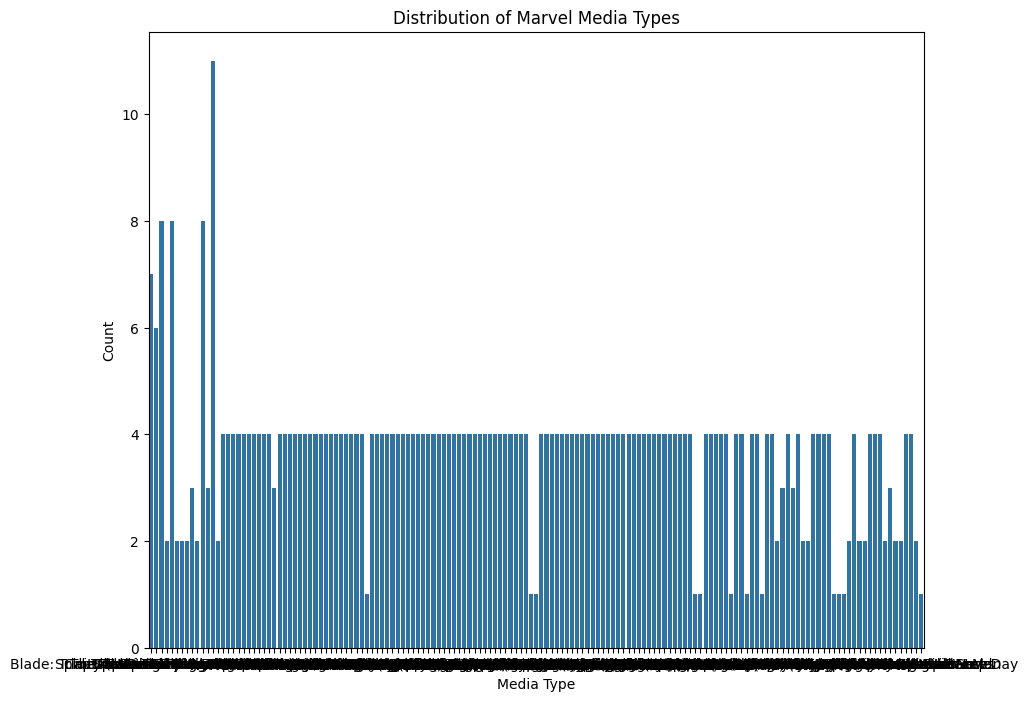

In [46]:
plt.figure(figsize=(10, 8))

sns.countplot(
    data=df,
    x="title"
)

plt.title(
    "Distribution of Marvel Media Types"
)

plt.xlabel("Media Type")
plt.ylabel("Count")

plt.show()

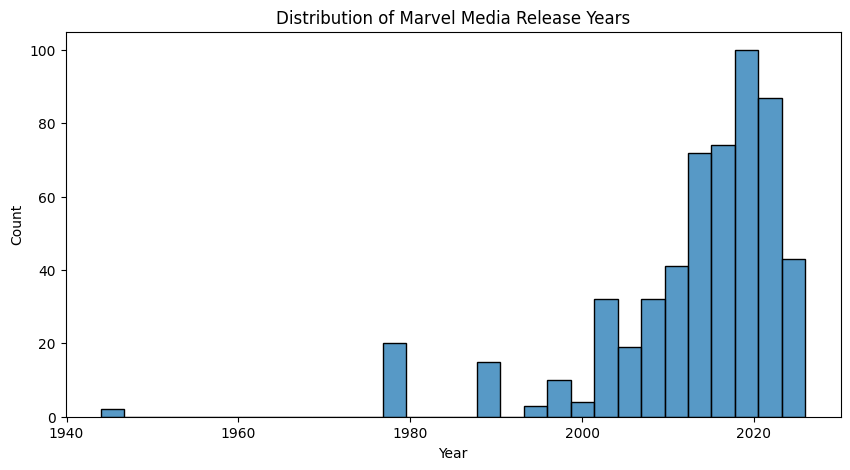

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="year",
    bins=30
)

plt.title(
    "Distribution of Marvel Media Release Years"
)

plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

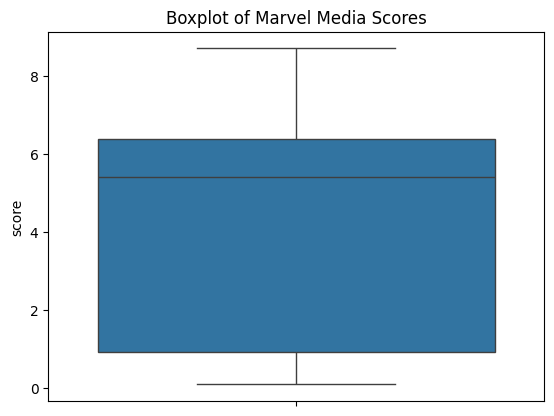

In [50]:


sns.boxplot(
    data=df,
    y="score",
)

plt.title(
    "Boxplot of Marvel Media Scores"
)

plt.show()

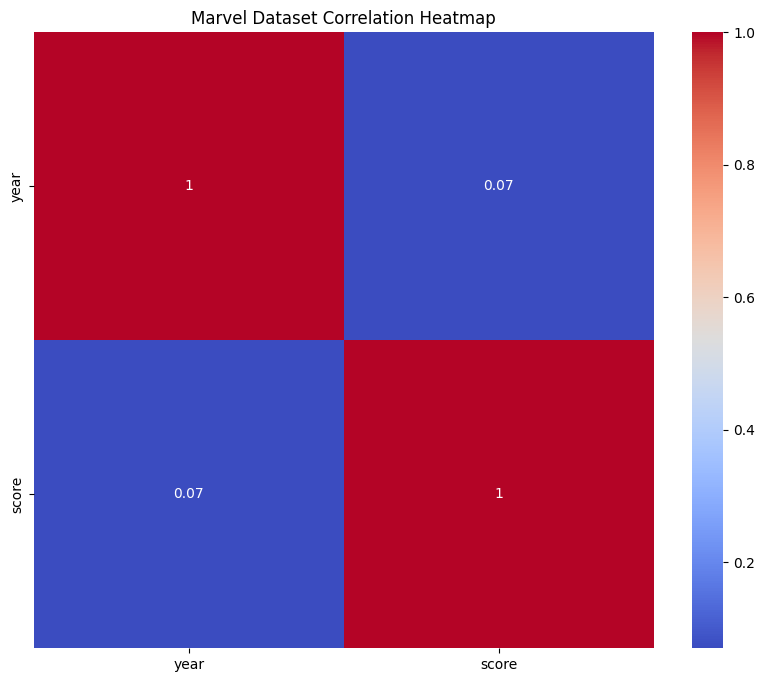

In [51]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    data=correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Marvel Dataset Correlation Heatmap"
)

plt.show()